### Intervalos de Confianza

Un intervalo de confianza bilateral $[\hat{\theta}_L, \hat{\theta}_U]$ a un nivel de confianza de $(1-\alpha)100$% satisface 
\begin{align}
\mathbb{P}(\hat{\theta}_L\leq \theta \leq \hat{\theta}_U)=1-\alpha,
\end{align}
donde $\hat{\theta}_L$ se denomina límite confianza inferior y $\hat{\theta}_U$ límite de confianza superior.

Intervalos de confianza unilaterales:
$\newline$
    a) inferior $[\hat{\theta}, \infty):$ $\newline$ 
$    \begin{align}
    \mathbb{P}(\hat{\theta}_L\leq \theta)=1-\alpha.
    \end{align}$
    b) superior  $(-\infty, \hat{\theta}_U]:$ $\newline$
$    \begin{align}
    \mathbb{P}(\theta \leq \hat{\theta}_U)=1-\alpha.
    \end{align}$

<img src="int-conf.jpeg">

Un método para encontrar intervalos de confianza se denomina $\textit{método del pivote}$. Éste
consiste en determinar una cantidad que actúe como pivote y que posea las dos características
siguientes:

1. Que sea una función de las medidas muestrales y el parámetro desconocido $\theta$, donde $\theta$
sea la única cantidad desconocida.
2. Que su distribución de probabilidad no dependa del parámetro $\theta$.

$\textbf{Ejemplo}$ Intervalos de confianza para el parámetro $\mu$ de una población normal con $\sigma$ conocida.

Sea $X$ una v.a. normal con media poblacional $\mu$ desconocida y desviación poblacional $\sigma$ conocida. Sea $X_1, \dots, X_n$ una muestra aleatoria de $X$, con media muestral $\bar{X}$. Determinar un intervalo de confianza bilateral para $\mu$ con nivel de confianza $1-\alpha$. Para fines prácticos supongamos $\alpha=0.5$.

De acuerdo con la definición buscamos un intervalo $[\hat{\theta}_L, \hat{\theta}_U]$ tal que
\begin{align}
\mathbb{P}(\hat{\theta}_L\leq \theta \leq \hat{\theta}_U)=1-\alpha,
\end{align}

Un candidato a pivote es:
    $\begin{align}
    Z=\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}\sim N(0,1)
    \end{align}$

Entonces
\begin{align}
\mathbb{P}(-a \leq \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \leq a)=0.95
\end{align}

así, $0.95=\mathbb{P}(-a \leq Z \leq a)=\varPhi(a)-\varPhi(-a)=2\varPhi(a)-1$

Entonces, $a=1.95$.

In [1]:
from scipy.stats import norm
norm.ppf(0.975)

1.959963984540054

De este modo, 
\begin{align}
0.95=\mathbb{P}(-1.95 \leq \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \leq 1.95)
\end{align}

Despejando $\mu$, obtenemos

\begin{align}
\mathbb{P}(\bar{X}-1.95\frac{\sigma}{\sqrt{n}}\leq \mu \leq \bar{X}+1.95\frac{\sigma}{\sqrt{n}})=0.95.
\end{align}

Por lo tanto, la probabilidad que la media poblacional $\mu$ de $X$ se encuentre dentro del intervalo
\begin{align}
(\bar{X}-1.95\frac{\sigma}{\sqrt{n}}, \bar{X}+1.95\frac{\sigma}{\sqrt{n}})
\end{align}
es 0.95: es un intervalo de confianza del 95%.

En general, si una población $X$ Normal con $\mu$ desconocida y $\sigma$-conocida, tiene como intervalo de confianza de $(1-\alpha)$ 100%:

$   \begin{align}
    (\bar{X}-z_{1-\frac{\alpha}{2}}\frac{\sigma}{\sqrt{n}}, \bar{X}+z_{1-\frac{\alpha}{2}}\frac{\sigma}{\sqrt{n}})
    \end{align}$

donde $z_{1-\frac{\alpha}{2}}$ es el $(1-\frac{\alpha}{2})$ -cuantil de la Normal estandar, i.e. $\mathbb{P}(Z\leq z_{1-\frac{\alpha}{2}})=1-\frac{\alpha}{2}$ . 

## Intervalos de confianza para el parámetro $\mu$ de una población con $\sigma$ conocida y tamaño muestral grande $n$.

In [2]:
mu=1.5
sigma=1
poblacion=norm.rvs(loc=mu, scale=sigma, size=10**6)
poblacion[:10]

array([3.96965895, 2.34874628, 0.63416178, 2.97801002, 0.75233548,
       1.68075476, 0.6963331 , 1.60041841, 3.03499705, 1.11353619])

In [ ]:
import numpy as np

def ICZ(x, sigma, alpha):  #intervalo de confianza?
    n=len(x)
    media_x=np.mean(x)
    z_critico=norm.ppf(1 - alpha/2)
    
    inferior=media_x-z_critico * (sigma / np.sqrt(n))
    superior=media_x+z_critico * (sigma / np.sqrt(n))
    
    return inferior, superior

M=np.zeros((100, 2))
alpha=0.05  

for i in range(100):
    muestra=np.random.choice(poblacion, size=50, replace=True)
    M[i, :] = ICZ(muestra, sigma, alpha)

M[:10, :]

array([[1.19648835, 1.75084988],
       [1.1998872 , 1.75424873],
       [1.35053325, 1.90489478],
       [1.13235967, 1.6867212 ],
       [1.22143125, 1.77579278],
       [1.5837058 , 2.13806733],
       [1.24488973, 1.79925126],
       [1.20484904, 1.75921057],
       [1.11419181, 1.66855334],
       [1.34986662, 1.90422815]])

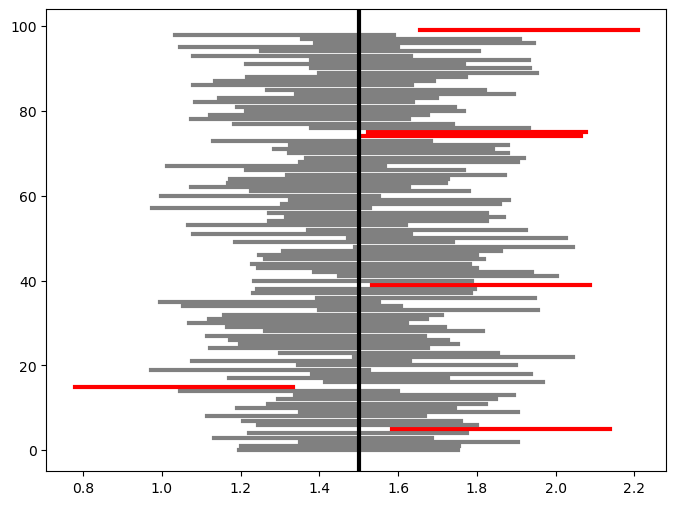

In [4]:
import matplotlib.pyplot as plt

xlim = (1.2, 1.8)
ylim = (0, 100)
plt.figure(figsize=(8, 6))
plt.plot([], [])  

def seg_int(i):
    color="grey"
    if (mu<M[i, 0]) or (mu>M[i, 1]):
        color="red"
    plt.plot([M[i, 0], M[i, 1]], [i, i], color=color, linewidth=3)

for i in range(100):
    seg_int(i)

plt.axvline(x=mu, color="black", linewidth=3)
plt.show()

## Intervalos de confianza para el parámetro $\mu$ de una población normal con $\sigma$ desconocida

En este caso el estadístico a aplicar es
\begin{align}
t=\frac{\bar{X}-\mu}{S_X/\sqrt{n}}
\end{align}

el cual corresponde a un pivote y su distribución corresponde a una densidad t-Student con $n-1$ g.l. y 
\begin{align}
S_X^2=\frac{1}{n-1}\sum_{k=1}^{n}(\bar{X}-\mu)^2
\end{align}

La densidad de una distribución $t_{\nu}$ con $\nu$ grados de libertad es:

<img src="t-stu.jpeg">

Para este caso siguiendo las mismas ideas del caso anterior se puede comprobar que in intervalo de confianza para $\mu$ de $(1-\alpha)$ 100% es:

$   \begin{align}
    (\bar{X}-t_{1-\frac{\alpha}{2}}\frac{s}{\sqrt{n}}, \bar{X}+t_{1-\frac{\alpha}{2}}\frac{s}{\sqrt{n}})
    \end{align}$

donde $t_{1-\frac{\alpha}{2}}$ corresponde al cuantil $(1-\frac{\alpha}{2})$ de una $t_{n-1}$.

## Ejercicio: Calcular el intervalo de confianza para $\mu$ de una población normal con $\sigma$ desconocida con los valores siguientes:  
n=24, $\bar{x}=518$, $\tilde{s}=40$, $\alpha=0.1$.

In [1]:
from scipy.stats import t

grados_libertad = 23 
nivel_probabilidad = 0.95
t.ppf(nivel_probabilidad, df=grados_libertad)


np.float64(1.7138715277470475)

In [ ]:
from scipy.stats import t
import numpy as np

alpha = 0.1
nivel_probabilidad = 1 - alpha/2
observaciones = 24
grados_libertad = observaciones - 1

media_muestral = 518
desviacion_muestral = 40

a = t.ppf(nivel_probabilidad, df=grados_libertad)

limite_inf = media_muestral - a * (desviacion_muestral / np.sqrt(observaciones))
limite_sup = media_muestral + a * (desviacion_muestral / np.sqrt(observaciones))

print(limite_inf, limite_sup)

504.0062975744516 531.9937024255485


In [4]:
def intervalo_t(alpha, n, media_muestral, desviacion_muestral):
    nivel_probabilidad = 1 - alpha/2
    grados_libertad = n - 1

    a = t.ppf(nivel_probabilidad, df=grados_libertad)

    limite_inf = media_muestral - a * (desviacion_muestral / np.sqrt(n))
    limite_sup = media_muestral + a * (desviacion_muestral / np.sqrt(n))

    return limite_inf, limite_sup

alpha = 0.1
n= 24
media_muestral = 518
desviacion_muestral = 40

lim_inf, lim_sup = intervalo_t(alpha=alpha, n=n, media_muestral=media_muestral, desviacion_muestral=desviacion_muestral)
print(lim_inf, lim_sup)

504.0062975744516 531.9937024255485


In [6]:
import numpy as np
from scipy.stats import ttest_1samp
import seaborn as sns

iris=sns.load_dataset('iris')
muestra_iris=iris.sample(n=30, replace=True)
long_pétalo_muestra=muestra_iris["petal_length"]
resultado_t_test=ttest_1samp(long_pétalo_muestra, popmean=muestra_iris["petal_length"].mean())
resultado_t_test.confidence_interval(0.95)

ConfidenceInterval(low=3.0985023258821434, high=4.441497674117857)

# Intervalos de confianza para el parámetro $p$ de una población de Bernoulli

## Clopper-Pearson

En el campo de la estadística, la distribución binomial se utiliza habitualmente en diversas aplicaciones, especialmente en situaciones en las que los resultados de interés pueden clasificarse en dos, es decir, un éxito o un fracaso. Las proporciones binomiales y sus intervalos de confianza se utilizan mucho en los ensayos clínicos para evaluar la tasa de respuesta y a veces se emplean en los demás ensayos para evaluar la incidencia global de acontecimientos adversos.  

Sea $\newline$

$\bullet$ $X$ una v.a. Bernoulli con $p$ desconocido. $\newline$

$\bullet$ $X_1, X_2, ...X_n$ una muestra aleatoria de $X$, con número de éxitos $x$.$\newline$
Entonces, la frecuencia relativa de éxitos es $\hat{p}=x/n$.


Un intervalo de confianza $(p_0,p_1)$ del $(1−\alpha)$ 100% nivel de confianza para $p$ de una población $X$ de Bernoulli se obtiene encontrando el $p_0$ más grande y el $p_1$ más pequeño tales que

<img src="Clopper.png">

$\bf{Ejemplo}$ Encontrar un intervalo de confianza para la proporción de flores con especie "setosa" dada una muestra de 60 flores. 

In [7]:
import numpy as np
import pandas as pd

muestra_flores_prop=iris.sample(n=60, replace=True)
muestra_flores_prop.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
65,6.7,3.1,4.4,1.4,versicolor
4,5.0,3.6,1.4,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
109,7.2,3.6,6.1,2.5,virginica
50,7.0,3.2,4.7,1.4,versicolor
42,4.4,3.2,1.3,0.2,setosa
47,4.6,3.2,1.4,0.2,setosa
88,5.6,3.0,4.1,1.3,versicolor
32,5.2,4.1,1.5,0.1,setosa
38,4.4,3.0,1.3,0.2,setosa


In [8]:
from scipy.stats import binomtest

numero_flores_setosa=(muestra_flores_prop["species"]=="setosa").sum()
intervalo=binomtest(numero_flores_setosa, 60, alternative='two-sided')
intervalo.proportion_ci(0.95)

ConfidenceInterval(low=0.2459406104372874, high=0.501030717643696)

# Intervalo de confianza para la varianza de una población normal

Consideramos una v.a. $X$ normal con media $\mu$ y varianza $\sigma^2$ desconocidas. Sea $X_1, ..., X_n$ una muestra aleatoria de  
$X$ y varianza muestral $S^2$. Bajo estas condiciones un estadístico pivote es:
$    \begin{align}
    \frac{(n-1)S^2}{\sigma^2}
    \end{align}$

la cual tiene una distribuciíon $\chi^2$ con $n-1$ grados de libertad.

De este modo podemos encontrar un intevalo de confianza:
$    \begin{align}
    \left(\frac{(n-1)S^2}{\chi^{2}_{1-\frac{\alpha}{2}}},\frac{(n-1)S^2}{\chi^{2}_{\frac{\alpha}{2}}} \right)
    \end{align}$

$\bf{Ejemplo}$: Un algoritmo probabilístico depende de la semilla de aleatorización que se genera en cada paso. Para saber si la semilla influye mucho en el resultado se ejecuta el algoritmo varias veces hasta obtener un resultado similar y se estudia la varianza de su tiempo de ejecución.

Queremos ver si la desviación típica $\sigma$ es menor o igual a 30.

Se supone que la distribución del tiempo de ejecución del algoritmo es aproximadamente normal.

In [9]:
import numpy as np
from scipy.stats import chi2


tiempo=np.array([12, 13, 13, 14, 14, 14, 15, 15, 16, 17, 17, 18, 18, 19, 19, 25, 25, 26, 27, 30,
                   33, 34, 35, 40, 40, 51, 51, 58, 59, 83])
n=len(tiempo)
var_muestral_tiempo=np.var(tiempo, ddof=1)
alpha=0.05
cuantil_izquierda=chi2.ppf(1 - alpha/2, df=n-1)
cuantil_derecha=chi2.ppf(alpha/2, df=n-1)
valor_izquierdo=(n - 1) * var_muestral_tiempo / cuantil_izquierda
valor_derecho=(n - 1) * var_muestral_tiempo / cuantil_derecha
np.sqrt([valor_izquierdo, valor_derecho])

array([13.82977493, 23.34431758])

# Bootstrap o remuestreo 

La idea principal del Bootstrap es realizar múltiples re-muestreos (con reemplazo) de la muestra original para obtener una aproximación empírica de la distribución de la estadística de interés. En específico, para intervalos de confianza se pueden seguir los puntos siguientes: $\newline$

$\bullet$ Remuestrear la muestra: tomar muchas muestras aleatorias simples de la muestra de la que disponemos, cada una de ellas del mismo tamaño que la muestra original

$\bullet$ Calcular el estimador sobre cada una de estas submuestras.

$\bullet$ Organizar los resultados en un vector.

$\bullet$ Usar este vector para calcular un intervalo de confianza.

$\textbf{método}$ $\textbf{de}$ $\textbf{los}$ $\textbf{percentiles}$. en el que se toman como extremos del intervalo de confianza del  r de estimadores.

In [10]:
datos = np.array([
            81.372918, 25.700971, 4.942646, 43.020853, 81.690589, 51.195236,
            55.659909, 15.153155, 38.745780, 12.610385, 22.415094, 18.355721,
            38.081501, 48.171135, 18.462725, 44.642251, 25.391082, 20.410874,
            15.778187, 19.351485, 20.189991, 27.795406, 25.268600, 20.177459,
            15.196887, 26.206537, 19.190966, 35.481161, 28.094252, 30.305922])

(array([1., 0., 1., 1., 2., 6., 2., 2., 3., 2., 0., 1., 1., 1., 1., 1., 1.,
        0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2.]),
 array([ 4.942646  ,  7.50091077, 10.05917553, 12.6174403 , 15.17570507,
        17.73396983, 20.2922346 , 22.85049937, 25.40876413, 27.9670289 ,
        30.52529367, 33.08355843, 35.6418232 , 38.20008797, 40.75835273,
        43.3166175 , 45.87488227, 48.43314703, 50.9914118 , 53.54967657,
        56.10794133, 58.6662061 , 61.22447087, 63.78273563, 66.3410004 ,
        68.89926517, 71.45752993, 74.0157947 , 76.57405947, 79.13232423,
        81.690589  ]),
 <BarContainer object of 30 artists>)

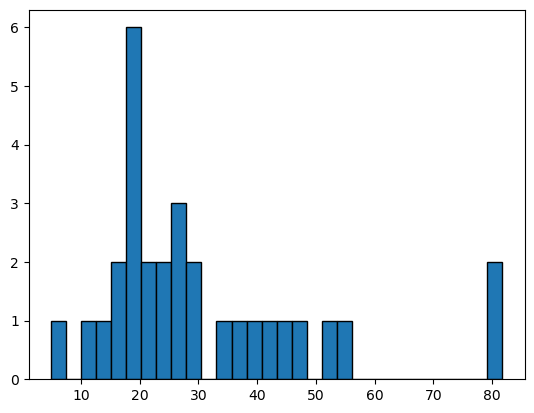

In [11]:
import matplotlib.pyplot as plt
plt.hist(datos, bins=30, edgecolor='black')

In [12]:
def calcular_estadistico(x):
    
    estadistico=np.mean(x)
    
    return(estadistico)

In [13]:
from tqdm import tqdm

In [14]:
def bootstraping(x, fun_estadistico, n_iteraciones):
    n=len(x)
    dist_boot=np.full(shape=n_iteraciones, fill_value=np.nan)
    
    for i in tqdm(range(n_iteraciones)):
        resample=np.random.choice(x, size=n, replace=True)
        dist_boot[i]=fun_estadistico(resample)
        
    return dist_boot

In [15]:
dist_boot=bootstraping(x=datos, fun_estadistico=calcular_estadistico, n_iteraciones=10000)

100%|██████████| 10000/10000 [00:00<00:00, 37734.75it/s]


In [16]:
dist_boot

array([32.26561217, 38.39891383, 35.0278379 , ..., 35.59954197,
       30.3927512 , 32.98833757])

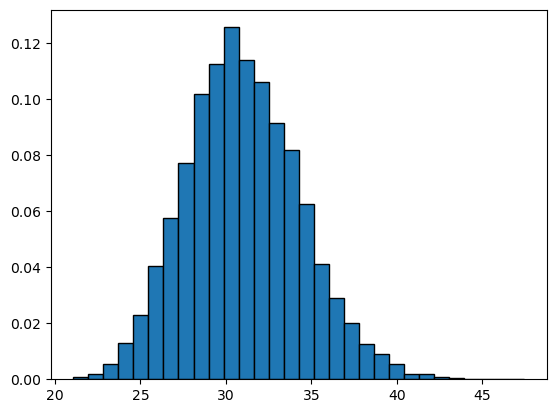

In [17]:
plt.hist(dist_boot, bins=30, density=True, edgecolor='black')
plt.show()

In [18]:
np.quantile(a=dist_boot, q=[0.025, 0.975])

array([24.92860875, 37.99999525])

$\textbf{Ejemplo}$: Encontrar un intervalo de confianza para la varianza de la longitud del pétalo de la tabla de datos iris.

In [19]:
datos2=muestra_flores_prop['petal_length']

In [20]:
def calcular_estadistico2(x):
    
    estadistico=np.var(x)
    
    return(estadistico)

In [21]:
dist_boot2=bootstraping(x=datos2, fun_estadistico=calcular_estadistico2, n_iteraciones=9999)

100%|██████████| 9999/9999 [00:00<00:00, 15958.03it/s]


In [22]:
dist_boot2

array([3.155475  , 3.273275  , 2.93169722, ..., 3.28509722, 2.92616389,
       3.62776389])

In [23]:
cuantiles=np.quantile(a=dist_boot2, q=[0.025, 0.975])
cuantiles

array([2.55064764, 3.79768667])